In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

df = pd.read_csv("../outputs/london_features_dataset.csv")
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp").reset_index(drop=True)

feature_cols = [
    "hour_of_day",
    "day_of_week",
    "month",
    "year",
    "day",
    "lag_1",
    "lag_2",
    "lag_3",
    "rolling_mean_3"
]

target_col = "all_motor_vehicles"

df = df.sort_values(["count_point_id", "timestamp"]).reset_index(drop=True)

def split_group(group):
    split_index = int(len(group) * 0.8)
    group = group.copy()
    group["set"] = "train"
    group.iloc[split_index:, group.columns.get_loc("set")] = "test"
    return group

df = df.groupby("count_point_id", group_keys=False).apply(split_group)

train_df = df[df["set"] == "train"]
test_df = df[df["set"] == "test"]

X_train = train_df[feature_cols]
y_train = train_df[target_col]

X_test = test_df[feature_cols]
y_test = test_df[target_col]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (176456, 9)
Test shape: (44925, 9)


/var/folders/dv/56245rkx5zzcn8v4sx0xq87m0000gn/T/ipykernel_65693/1663937342.py:35: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("count_point_id", group_keys=False).apply(split_group)


In [36]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

In [37]:
rf_mae = mean_absolute_error(y_test, rf_preds)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))

print("Random Forest MAE:", rf_mae)
print("Random Forest RMSE:", rf_rmse)

Random Forest MAE: 145.93772309404562
Random Forest RMSE: 243.31728053780697


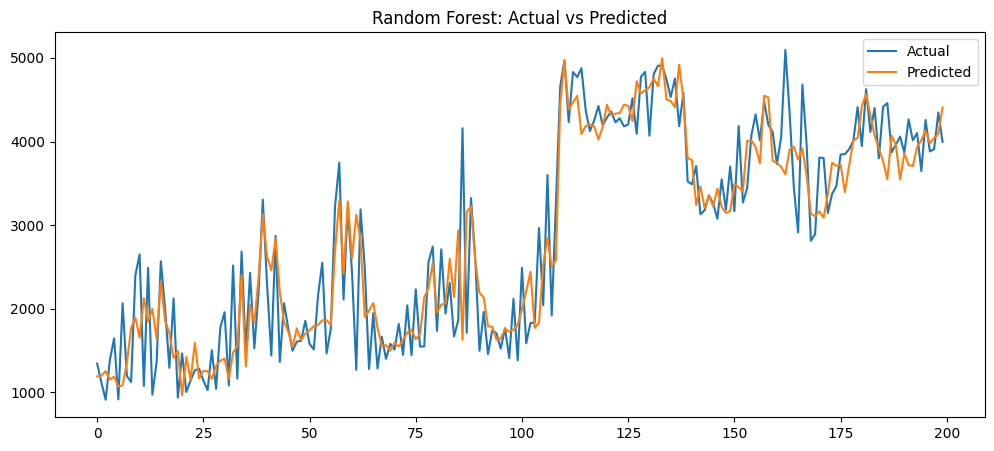

In [38]:
plt.figure(figsize=(12, 5))
plt.plot(y_test.values[:200], label="Actual")
plt.plot(rf_preds[:200], label="Predicted")
plt.legend()
plt.title("Random Forest: Actual vs Predicted")
plt.show()

In [39]:
plt.figure(figsize=(12, 5))
plt.plot(y_test.values[:200], label="Actual")
plt.plot(rf_preds[:200], label="Predicted")
plt.legend()
plt.title("Random Forest: Actual vs Predicted")
plt.savefig("../outputs/random_forest_actual_vs_predicted.png", bbox_inches="tight")
plt.close()

In [40]:
import pandas as pd

results_df = pd.DataFrame({
    "Model": ["Baseline", "Random Forest"],
    "MAE": [166.50717124127112, 145.93772309404562],
    "RMSE": [271.251295868288, 243.31728053780697]
})

print(results_df)

           Model         MAE        RMSE
0       Baseline  166.507171  271.251296
1  Random Forest  145.937723  243.317281


In [41]:
results_df.to_csv("../outputs/model_results_summary.csv", index=False)
print("Results saved.")

Results saved.


In [47]:
from sklearn.metrics import r2_score

print("Random Forest R2:", r2_score(y_test, rf_preds))

Random Forest R2: 0.9426333919797522


In [48]:
import pandas as pd

results_df = pd.DataFrame({
    "Model": ["Baseline", "Random Forest"],
    "MAE": [166.50717124127112, 145.93772309404562],
    "RMSE": [271.251295868288, 243.31728053780697],
    "R2": [0.9286659272175428, 0.9426333919797522]
})

print(results_df)

           Model         MAE        RMSE        R2
0       Baseline  166.507171  271.251296  0.928666
1  Random Forest  145.937723  243.317281  0.942633


In [49]:
from pathlib import Path

output_path = Path("../outputs")
output_path.mkdir(exist_ok=True)

results_df.to_csv(output_path / "final_model_comparison.csv", index=False)
print("Final model comparison saved.")

Final model comparison saved.


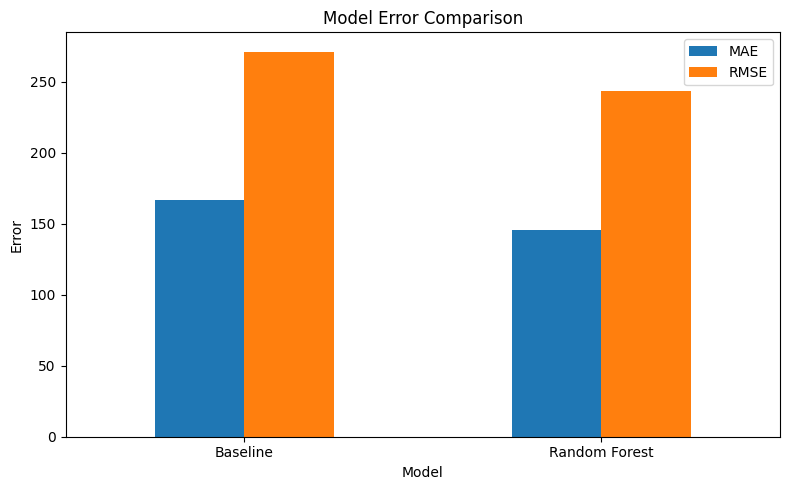

In [50]:
import matplotlib.pyplot as plt

results_df.set_index("Model")[["MAE", "RMSE"]].plot(kind="bar", figsize=(8,5))
plt.title("Model Error Comparison")
plt.ylabel("Error")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

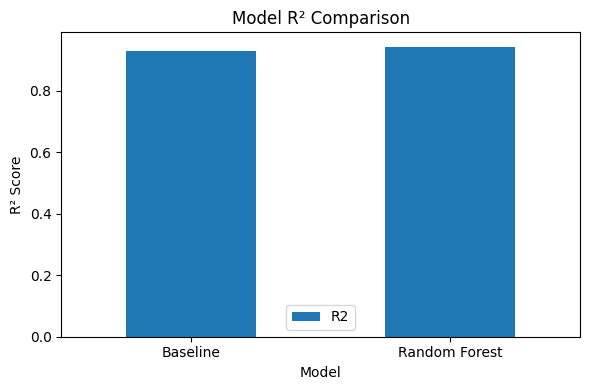

In [51]:
results_df.set_index("Model")[["R2"]].plot(kind="bar", figsize=(6,4))
plt.title("Model R² Comparison")
plt.ylabel("R² Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [52]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(feature_importance)

          Feature  Importance
8  rolling_mean_3    0.891716
6           lag_2    0.025614
7           lag_3    0.023240
5           lag_1    0.020190
0     hour_of_day    0.011532
4             day    0.009600
3            year    0.008470
2           month    0.005163
1     day_of_week    0.004473


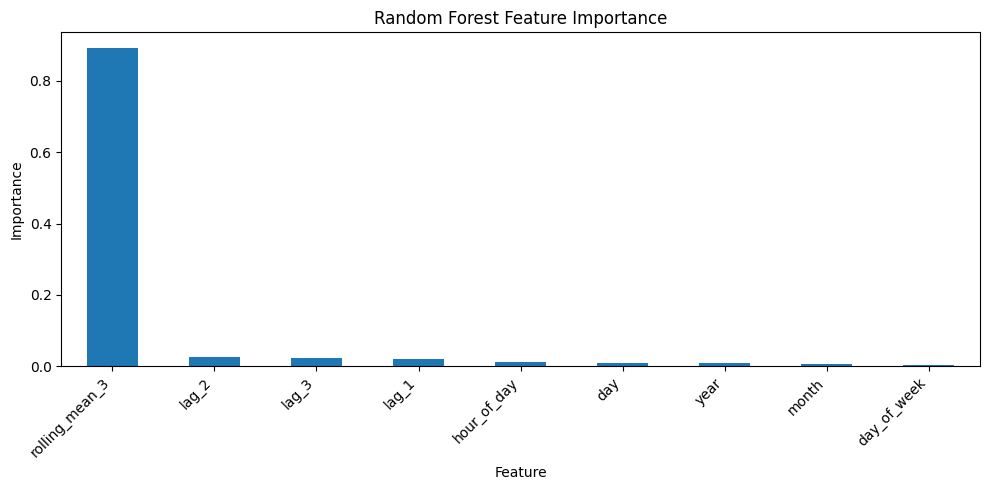

In [53]:
feature_importance.plot(
    x="Feature",
    y="Importance",
    kind="bar",
    figsize=(10,5),
    legend=False
)

plt.title("Random Forest Feature Importance")
plt.ylabel("Importance")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [54]:
feature_importance.to_csv(output_path / "feature_importance.csv", index=False)
print("Feature importance saved.")

Feature importance saved.


In [55]:
error_df = X_test.copy()
error_df["actual"] = y_test.values
error_df["predicted"] = rf_preds
error_df["absolute_error"] = abs(error_df["actual"] - error_df["predicted"])
error_df["residual"] = error_df["actual"] - error_df["predicted"]

print(error_df.head())

     hour_of_day  day_of_week  month  year  day   lag_1   lag_2   lag_3  \
148           12            3      5  2011   26  1120.0  1249.0  1175.0   
149           12            3      5  2011   26  1249.0  1175.0  1249.0   
150           13            3      5  2011   26  1345.0  1120.0  1249.0   
151           13            3      5  2011   26   912.0  1345.0  1120.0   
152           14            3      5  2011   26   917.0  1387.0   912.0   

     rolling_mean_3  actual  predicted  absolute_error  residual  
148     1181.333333  1345.0    1191.37          153.63    153.63  
149     1224.333333  1120.0    1198.05           78.05    -78.05  
150     1238.000000   912.0    1254.00          342.00   -342.00  
151     1125.666667  1387.0    1153.90          233.10    233.10  
152     1072.000000  1646.0    1188.71          457.29    457.29  


In [56]:
worst_errors = error_df.sort_values("absolute_error", ascending=False).head(10)
print(worst_errors)

        hour_of_day  day_of_week  month  year  day   lag_1   lag_2   lag_3  \
32880             7            1      9  2022   20  1530.0  1573.0  2006.0   
32856             7            2      4  2020   29  5779.0  5336.0  5886.0   
102965            7            3      6  2021   10  1928.0  1671.0  2051.0   
199160           17            0      6  2014   16  5658.0  2138.0  4185.0   
93582             7            1      7  2019    9  6880.0  6392.0  6503.0   
7758              7            0      4  2020   20  4996.0  4380.0  4749.0   
517               7            3      7  2022   14  2308.0  1669.0  1943.0   
220697            7            3      5  2023   18  2533.0  4225.0  3287.0   
61885             7            1      5  2020   19  3317.0  3318.0  3721.0   
121252           15            4      9  2021   17     0.0  2146.0     0.0   

        rolling_mean_3  actual  predicted  absolute_error  residual  
32880      1703.000000  6196.0    1891.12         4304.88   4304.88  
3

In [57]:
if "day_of_week" in error_df.columns:
    day_error = error_df.groupby("day_of_week")["absolute_error"].mean().sort_values(ascending=False)
    print(day_error)
else:
    print("day_of_week not found in features.")

day_of_week
0    150.360415
4    149.777183
3    146.723259
2    141.880549
1    141.859862
Name: absolute_error, dtype: float64


In [58]:
if "hour_of_day" in error_df.columns:
    hour_error = error_df.groupby("hour_of_day")["absolute_error"].mean().sort_values(ascending=False)
    print(hour_error)
else:
    print("hour_of_day not found in features.")

hour_of_day
7     321.467429
8     199.458098
9     168.446044
16    153.393260
15    149.216789
17    147.905361
18    146.569314
14    134.544778
10    120.112607
13    110.636400
12     97.812284
11     97.610770
Name: absolute_error, dtype: float64


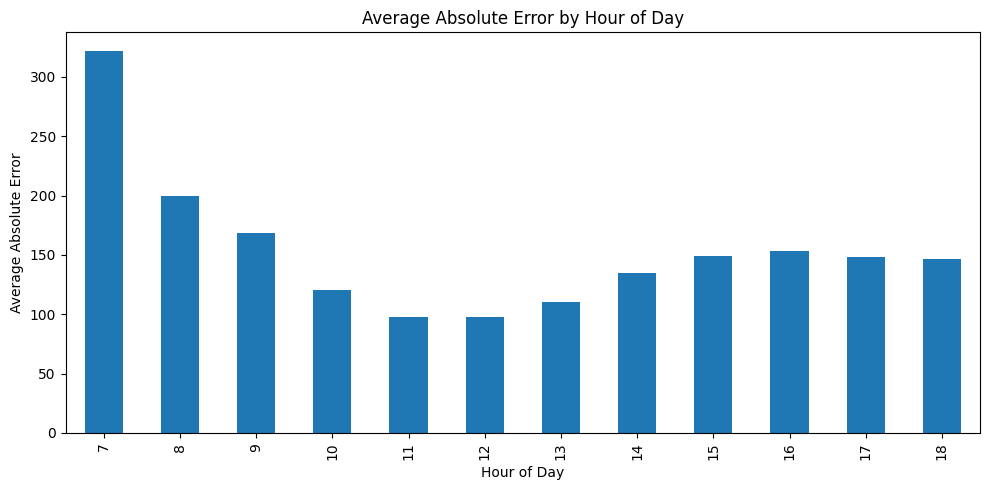

In [59]:
if "hour_of_day" in error_df.columns:
    hour_error.sort_index().plot(kind="bar", figsize=(10,5))
    plt.title("Average Absolute Error by Hour of Day")
    plt.ylabel("Average Absolute Error")
    plt.xlabel("Hour of Day")
    plt.tight_layout()
    plt.show()

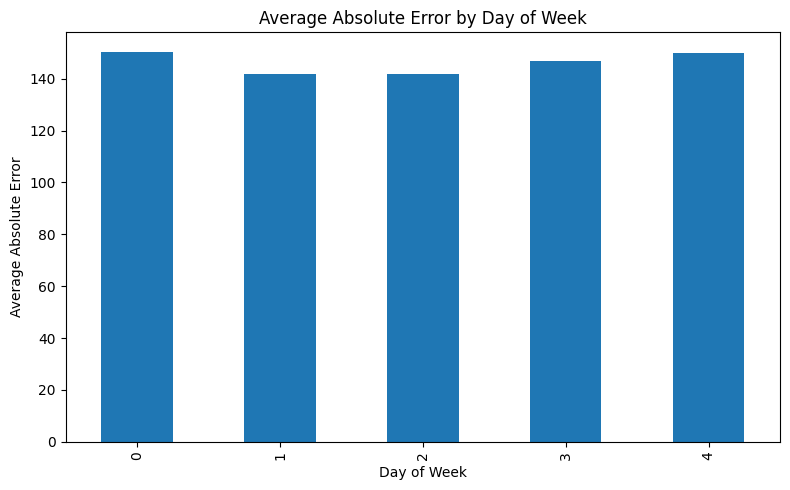

In [60]:
if "day_of_week" in error_df.columns:
    day_error.sort_index().plot(kind="bar", figsize=(8,5))
    plt.title("Average Absolute Error by Day of Week")
    plt.ylabel("Average Absolute Error")
    plt.xlabel("Day of Week")
    plt.tight_layout()
    plt.show()